# Salary Efficiency Findings

This notebook turns the salary-efficiency output into a smaller set of findings. The goal is not just to list players, but to understand which player-seasons, teams, and position groups created the most contract-cost surplus.

Important caveat: salary is measured with `inflated_apy`, so this is a contract-efficiency view rather than exact cap-hit accounting.

## Load Findings Pipeline

The findings are built from `src.salary_findings` so the same tables can be regenerated from the command-line pipeline. This keeps the notebook focused on interpretation instead of copying analysis logic across places.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


def find_project_root(expected_file="outputs/tables/salary_efficiency_2016_2025.csv"):
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(f"Could not find {expected_file} from {Path.cwd()}")


project_root = find_project_root()
sys.path.insert(0, str(project_root))

from src.salary_findings import build_salary_finding_tables

project_root

PosixPath('/Users/kylelevesque/Desktop/nfl-player-value-analysis-1')

## Build Finding Tables

I filter to matched salary rows with at least 8 games played. That removes many tiny-sample seasons while still keeping enough players for position and team comparisons.

In [2]:
outputs = build_salary_finding_tables(project_root=project_root, save_outputs=True)
tables = outputs["tables"]

summary_metrics = tables["summary_metrics"]
top_surplus = tables["top_surplus"]
high_cost_underperformers = tables["high_cost_underperformers"]
rookie_surplus = tables["rookie_surplus"]
veteran_values = tables["veteran_values"]
team_season = tables["team_season"]
team_summary = tables["team_summary"]
position_salary_tiers = tables["position_salary_tiers"]
season_trends = tables["season_trends"]
finding_base = tables["finding_base"]

print("Finding sample:", finding_base.shape)
print("Report saved to:", outputs["report_path"])

Finding sample: (3531, 34)
Report saved to: /Users/kylelevesque/Desktop/nfl-player-value-analysis-1/report/salary_efficiency_findings.md


## Summary Metrics

This quick snapshot checks the size of the findings sample and the main headline result. The sample is smaller than the full value-score dataset because it requires a salary match and a minimum-games filter.

In [3]:
display(summary_metrics)

,metric,value,note
0,finding_sample_rows,3531,Matched salary rows with at least 8 games played.
1,seasons_covered,10,Number of seasons in the findings sample.
2,median_salary_millions,2.442074,Median inflated APY in the findings sample.
3,median_value_above_expected_salary,-0.0958,Median residual from the salary-efficiency model.
4,top_team_season,2018 KC,Highest total value above expected salary amon...
5,top_team_season_surplus,14.032227,Total residual for that team-season.


## Top Surplus Player-Seasons

These are the player-seasons where actual value score was farthest above expected value after accounting for salary, position, age, experience, draft slot, and games played.

In [4]:
display(
    top_surplus[[
        "season", "player_display_name", "position", "team",
        "games_played", "salary_millions", "value_score",
        "value_above_expected_salary"
    ]].head(15).round(3)
)

,season,player_display_name,position,team,games_played,salary_millions,value_score,value_above_expected_salary
4601,2025,Puka Nacua,WR,LA,16,1.368,6.057,5.958
508,2017,Rob Gronkowski,TE,NE,13,22.478,5.717,5.182
894,2017,Alvin Kamara,RB,NO,16,1.739,4.946,4.748
2849,2022,Travis Kelce,TE,KC,17,21.750,5.166,4.472
3558,2023,CeeDee Lamb,WR,DAL,17,5.323,4.531,4.171
2538,2021,Cooper Kupp,WR,LA,17,23.935,4.930,4.160
1912,2020,Travis Kelce,TE,KC,15,21.750,4.787,4.151
1223,2018,George Kittle,TE,SF,16,1.217,4.193,4.036
4483,2025,George Pickens,WR,DAL,17,2.442,4.135,3.945
4545,2025,Jaxon Smith-Njigba,WR,SEA,17,4.829,4.240,3.880


## High-Cost Underperformers

This table only considers players at or above the 75th salary percentile within their season-position group. I read this as contract-cost underperformance, not exact cap-hit underperformance.

In [5]:
display(
    high_cost_underperformers[[
        "season", "player_display_name", "position", "team",
        "games_played", "salary_millions", "value_score",
        "value_above_expected_salary"
    ]].head(15).round(3)
)

,season,player_display_name,position,team,games_played,salary_millions,value_score,value_above_expected_salary
4680,2025,Ashton Jeanty,RB,LV,17,9.681,-6.207,-6.844
372,2016,Todd Gurley,RB,LA,16,7.265,-4.116,-4.603
1151,2018,David Johnson,RB,ARI,16,22.097,-3.715,-4.494
2007,2020,Ezekiel Elliott,RB,DAL,15,24.006,-3.485,-4.183
2964,2022,Alvin Kamara,RB,NO,15,22.795,-3.163,-3.847
2961,2022,Dalvin Cook,RB,MIN,17,19.148,-2.972,-3.700
1466,2019,Le'Veon Bell,RB,NYJ,15,21.006,-2.970,-3.601
3463,2023,Saquon Barkley,RB,NYG,14,13.521,-3.096,-3.552
4312,2025,Alvin Kamara,RB,NO,11,14.447,-3.082,-3.355
3398,2023,Austin Ekeler,RB,LAC,14,9.308,-2.940,-3.303


## Rookie-Contract Proxy Surplus

This view uses `years_exp <= 3` as a rough rookie-contract proxy. It is not perfect because some players can sign extensions early, but it is useful for finding low-cost surplus production.

In [6]:
display(
    rookie_surplus[[
        "season", "player_display_name", "position", "team",
        "games_played", "years_exp", "salary_millions",
        "value_above_expected_salary"
    ]].head(15).round(3)
)

,season,player_display_name,position,team,games_played,years_exp,salary_millions,value_above_expected_salary
4601,2025,Puka Nacua,WR,LA,16,2.0,1.368,5.958
894,2017,Alvin Kamara,RB,NO,16,0.0,1.739,4.748
3558,2023,CeeDee Lamb,WR,DAL,17,3.0,5.323,4.171
1223,2018,George Kittle,TE,SF,16,1.0,1.217,4.036
4483,2025,George Pickens,WR,DAL,17,3.0,2.442,3.945
4545,2025,Jaxon Smith-Njigba,WR,SEA,17,2.0,4.829,3.880
1666,2019,Chris Godwin Jr.,WR,TB,14,2.0,1.481,3.790
227,2016,Travis Kelce,TE,KC,16,3.0,18.173,3.765
4511,2025,Trey McBride,TE,ARI,17,3.0,20.497,3.608
1612,2019,George Kittle,TE,SF,14,2.0,1.217,3.558


## Team-Season Salary Efficiency

Team-season totals show where several efficient player-seasons stacked together. Because this uses skill-position `inflated_apy`, I would describe this as offensive contract-cost efficiency rather than total roster cap efficiency.

In [7]:
display(
    team_season[[
        "season", "team", "player_seasons", "total_salary_millions",
        "total_value_above_expected_salary", "high_efficiency_players",
        "low_efficiency_players"
    ]].head(15).round(3)
)

,season,team,player_seasons,total_salary_millions,total_value_above_expected_salary,high_efficiency_players,low_efficiency_players
79,2018,KC,10,68.577,14.032,6,1
139,2020,GB,15,101.552,14.008,9,0
207,2022,KC,13,131.472,13.041,8,0
258,2024,BAL,10,127.269,11.917,8,0
53,2017,NE,12,117.566,11.080,6,2
266,2024,DET,11,140.059,10.983,6,0
1,2016,ATL,11,107.464,10.853,8,0
252,2023,SF,12,103.311,10.831,6,0
309,2025,NE,11,73.358,10.500,8,1
98,2019,BAL,12,50.242,10.053,6,1


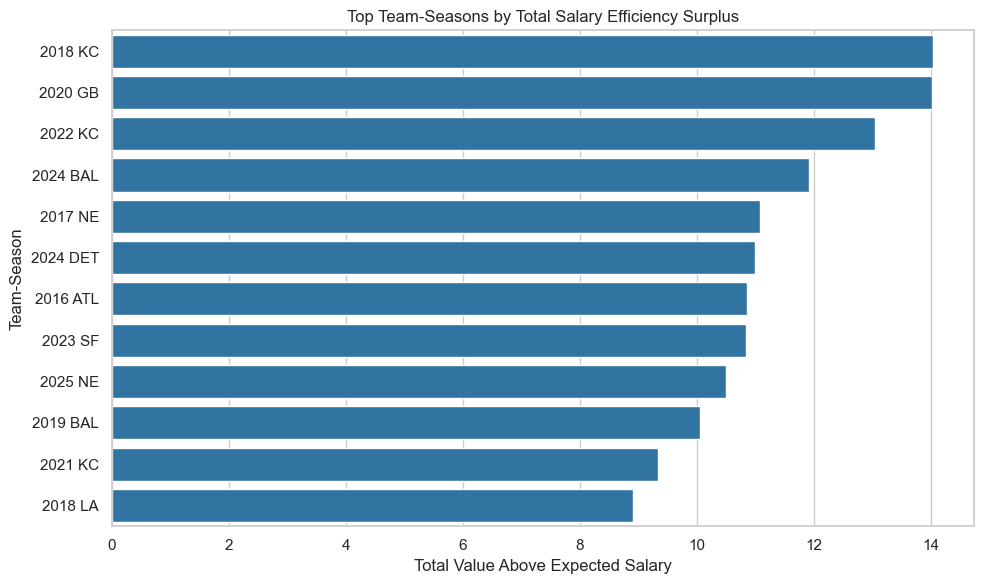

In [8]:
plt.figure(figsize=(10, 6))
plot_df = team_season.head(12).copy()
plot_df["team_season"] = plot_df["season"].astype(str) + " " + plot_df["team"]
sns.barplot(
    data=plot_df,
    y="team_season",
    x="total_value_above_expected_salary",
    color="#1f77b4",
)
plt.title("Top Team-Seasons by Total Salary Efficiency Surplus")
plt.xlabel("Total Value Above Expected Salary")
plt.ylabel("Team-Season")
plt.tight_layout()
plt.show()

## Position And Salary-Tier Pattern

This table helps check whether the residual model is still leaving obvious position patterns. Running backs stand out: high-cost RB seasons have a negative average residual, which supports the idea that RB salary efficiency is especially sensitive to contract timing and decline risk.

In [9]:
display(position_salary_tiers.round(3))

,position,salary_tier,player_seasons,median_salary_millions,mean_value_score,mean_value_above_expected_salary,median_value_above_expected_salary
3,QB,Low Cost,40,1.324,-0.272,0.056,-0.047
1,QB,Below Median Cost,66,5.424,-0.073,-0.081,-0.163
0,QB,Above Median Cost,107,13.888,0.119,-0.193,-0.242
2,QB,High Cost,127,51.214,0.728,0.101,0.059
7,RB,Low Cost,192,1.117,0.139,0.209,0.311
5,RB,Below Median Cost,224,1.401,-0.036,-0.012,0.037
4,RB,Above Median Cost,230,1.875,-0.004,-0.043,-0.008
6,RB,High Cost,280,7.685,-0.270,-0.617,-0.532
11,TE,Low Cost,134,1.163,-0.176,-0.047,-0.089
9,TE,Below Median Cost,190,1.506,-0.053,-0.008,-0.101


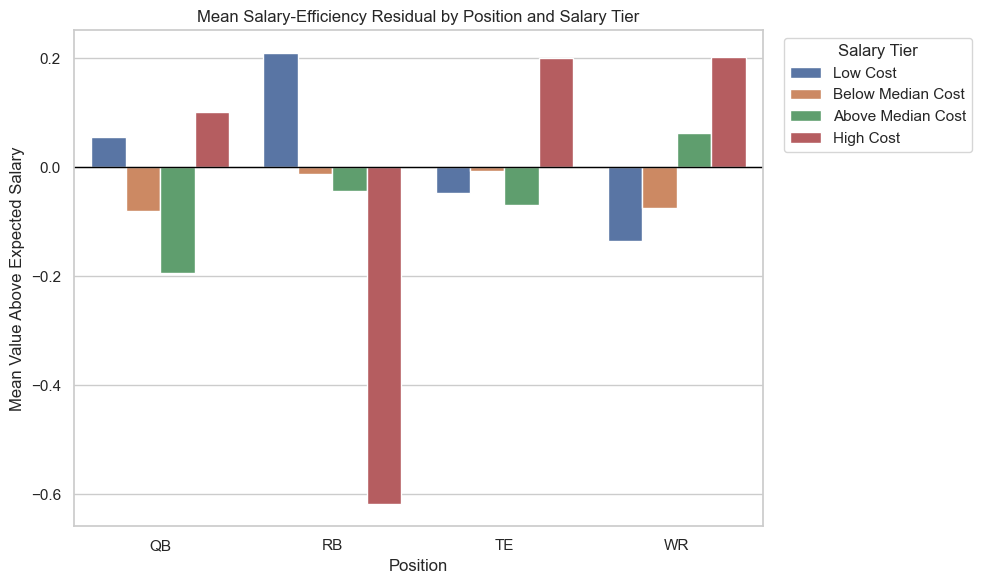

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=position_salary_tiers,
    x="position",
    y="mean_value_above_expected_salary",
    hue="salary_tier",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Mean Salary-Efficiency Residual by Position and Salary Tier")
plt.xlabel("Position")
plt.ylabel("Mean Value Above Expected Salary")
plt.legend(title="Salary Tier", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Main Interpretation

The strongest findings are about surplus concentration. A few elite player-seasons, especially on rookie or below-market contracts, create very large positive residuals. At the team level, the best seasons tend to combine one or two stars with several useful contributors.

The high-cost underperformer table is useful, but it needs more caution. A negative residual does not mean the contract was a bad decision by itself; injuries, role changes, team context, and non-receiving value can all matter.

## Exported Outputs

The findings tables and written report are saved so they can be reviewed without rerunning the notebook.

In [11]:
for path in sorted((project_root / "outputs" / "tables").glob("salary_findings_*.csv")):
    print(path)

print(outputs["report_path"])

/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_high_cost_underperformers.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_position_salary_tiers.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_rookie_contract_surplus.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_season_trends.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_summary_metrics.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_team_season.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_team_summary.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_top_surplus_players.csv
/Users/kylelevesque/Desktop/nfl-player-value-analysis-1/outputs/tables/salary_findings_veteran_values.csv
/Users/kylelevesque